In [1]:
import sys
import pandas as pd
import numpy as np
import torch

from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments    
)

import matplotlib.pyplot as plt

# Adiciona o diretório src ao path de forma mais robusta
sys.path.insert(0, '../')

from src import RepositorioDados
from src import evaluate_and_visualize

# Detecta o dispositivo e a precisão usada nas operações
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

c:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu | Precision: torch.float32


In [2]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'timestamp'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
LAGS = 3                     # Número de lags (dias anteriores) a incluir como features
USE_MEAN_FEATURES = True     # Incluir médias móveis como features
ID_COLUMNS = []             # Sem IDs (série única)

# Tamanhos das janelas: histórico 7 dias, previsão 1 dia (dados diários)
CONTEXT_LENGTH = 256         # Janela histórica: x dias passados
FORECAST_HORIZON = 1        # Prever: x dias à frente

TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # Frações treino/validação/teste

# Hyperparâmetros do modelo
PATCH_LENGTH = 1            # Tamanho do patch (1=sem patchificação, mantém cada dia)
BATCH_SIZE = 32             # Samples por batch (reduzir se GPU memory limitada)
NUM_WORKERS = 0             # Workers para data loading (0 em Windows)
EPOCHS = 50                 # Reduzido: 50→30 (volatilidade tem ciclos curtos)
LEARNING_RATE = 5e-4        # Taxa de aprendizado

D_MODEL = 64              # Dimensão do modelo (embedding)
NUM_ATTENTION_HEADS = 16     # Número de cabeças de atenção
NUM_HIDDEN_LAYERS = 2      # Número de camadas ocultas (reduzido para evitar overfitting)
FFN_DIM = 128              # Dimensão da feedforward network (aumentado para compensar menos camadas)
DROPOUT = 0.05              # Taxa de dropout
ATTENTION_DROPOUT = DROPOUT
SCALING = False            # Desativar escalonamento (já normalizamos os dados)

In [3]:
repo = RepositorioDados()
tsp, train_ds, valid_ds, test_ds, train_df, valid_df, test_df = repo.executar(timestamp_col=TIMESTAMP_COLUMN, train_frac=TRAIN_FRAC, valid_frac=VALID_FRAC, context_length=CONTEXT_LENGTH, target_col=TARGET_COLUMN, id_columns=ID_COLUMNS, forecast_horizon=FORECAST_HORIZON, use_mean_features=USE_MEAN_FEATURES, lags=LAGS)

Carregando dados de C:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt
Calculando features de volatilidade


In [4]:
# ==================== MÉTRICAS DE AVALIAÇÃO ====================
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(eval_pred):
    pred, labels = eval_pred
    pred = pred[0] if isinstance(pred, tuple) else pred

    # 1-step ahead
    pred_1 = pred[:, 0, 0]
    label_1 = labels[:, 0, 0]

    mse = mean_squared_error(label_1, pred_1)
    mae = mean_absolute_error(label_1, pred_1)
    rmse = np.sqrt(mse)
    mape = np.mean(
        np.abs((label_1 - pred_1) / (np.abs(label_1) + 1e-9))
    ) * 100

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [5]:
config = PatchTSTConfig(
    context_length=CONTEXT_LENGTH,
    patch_length=PATCH_LENGTH,
    num_input_channels=len(TARGET_COLUMN),
    patch_stride=PATCH_LENGTH,
    prediction_length=FORECAST_HORIZON,
    d_model=D_MODEL,
    num_attention_heads=NUM_ATTENTION_HEADS,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    ffn_dim=FFN_DIM,
    dropout=DROPOUT,
    head_dropout=ATTENTION_DROPOUT,
    pooling_type=None,
    channel_attention=True, # Ativação da atenção entre canais
    loss='mse',
    pre_norm=True,
    norm_type='batchnorm',
)

# config = PatchTSTConfig(
#             do_mask_input=False,
#             context_length=context_length,
#             patch_length=patch_length,
#             num_input_channels=len(config_params['target_col']),
#             patch_stride=patch_length,
#             prediction_length=forecast_horizon,
#             d_model=d_model,
#             num_attention_heads=num_attention_heads,
#             num_hidden_layers=num_hidden_layers,
#             ffn_dim=ffn_dim,
#             dropout=dropout,
#             head_dropout=dropout,
#             pooling_type=None,
#             channel_attention=True,
#             scaling='std',
#             loss='mse',
#             pre_norm=True,
#             norm_type='batchnorm',
#         )

model = PatchTSTForPrediction(
    config=config
    ).to(device).to(dtype)

In [6]:
train_args = TrainingArguments(
    output_dir="../models/patchtst_volatility",
    overwrite_output_dir=True,
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    dataloader_num_workers=NUM_WORKERS,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    fp16=(dtype == torch.float16),
    bf16=(dtype == torch.bfloat16),
    logging_dir="../logs/logs_patchtst_volatility",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    label_names=["future_values"]
)

early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=7,
    early_stopping_threshold=0.0
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

In [7]:
print("Iniciando o treinamento do PatchTST para volatilidade...")
trainer.train()

Iniciando o treinamento do PatchTST para volatilidade...


c:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Mse,Mae,Rmse,Mape
1,0.719900,0.042836,0.042836,0.141257,0.206969,75.538887
2,0.641200,0.036904,0.036904,0.082825,0.192105,74.456963
3,0.632400,0.032733,0.032733,0.089576,0.180923,43.478119
4,0.587900,0.030400,0.030400,0.085533,0.174357,46.118893
5,0.558300,0.030834,0.030834,0.091463,0.175597,50.146206
6,0.605500,0.035011,0.035011,0.120493,0.187113,47.001503
7,0.559700,0.031405,0.031405,0.091352,0.177216,47.394756
8,0.571500,0.033712,0.033712,0.119636,0.183609,41.697563
9,0.550800,0.031525,0.031525,0.101375,0.177553,40.647228
10,0.519800,0.036067,0.036067,0.111827,0.189912,47.358837


c:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is fo

TrainOutput(global_step=528, training_loss=0.5887939677093968, metrics={'train_runtime': 387.4864, 'train_samples_per_second': 197.813, 'train_steps_per_second': 6.194, 'total_flos': 2592669252096.0, 'train_loss': 0.5887939677093968, 'epoch': 11.0})

In [8]:
# MODEL_DIR = "../models/patchtst/context256_lags5_useFalse"

# # Usa a config salva junto ao modelo para evitar divergências
# config = PatchTSTConfig.from_pretrained(MODEL_DIR)

# # Carrega pesos safetensors da pasta (não use torch.load direto)
# model = PatchTSTForPrediction.from_pretrained(
#     MODEL_DIR,
#     config=config,
#     local_files_only=True,
#     dtype=dtype
# ).to(device)

# model.eval()
# print(f"Modelo carregado de {MODEL_DIR}")
import os
model_save_path = f"../models/patchtst/context{CONTEXT_LENGTH}_lags{LAGS}_use{str(USE_MEAN_FEATURES)}_v2"
trainer.save_model(model_save_path)

c:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



=== Scratch ===
MSE: 8.389599e-07
MAE: 3.533625e-04
RMSE: 9.159475e-04
MAPE: 8.405167e+01


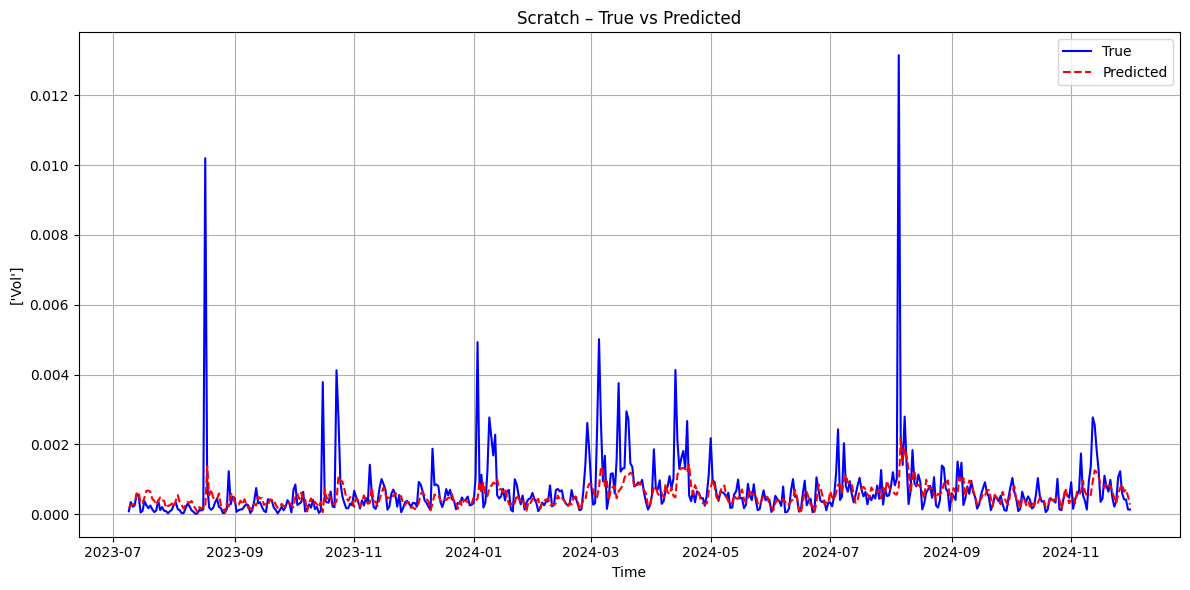

In [9]:
train_df = train_ds.datasets[0].data_df
test_df = test_ds.datasets[0].data_df

forecast, results, labels, preds = evaluate_and_visualize(
    model=model,
    test_dataset=test_ds,
    tsp=tsp,
    test_df=test_df,
    timestamp_col=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    context_length=CONTEXT_LENGTH,
    model_name="Scratch"
    )